In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

### Load Data
recipes_df = pd.read_csv("../data/cleaned_recipes3.csv")
# gdp_df_raw = pd.read_csv("../data/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_26433/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_26433.csv", skiprows=4)

In [ ]:
recipes_df.value_counts()

url                                                                                    title                                           steps                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [11]:
x = pd.read_csv("../data/recipes_df.csv")


In [14]:
x.value_counts()

url                                                                                    title                                           steps                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [4]:
recipes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4551 entries, 0 to 4550
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   url                   4551 non-null   object 
 1   title                 4551 non-null   object 
 2   steps                 4551 non-null   object 
 3   rating                4432 non-null   float64
 4   comments              4551 non-null   object 
 5   dish_type             1317 non-null   object 
 6   cuisine               3843 non-null   object 
 7   continent             4551 non-null   object 
 8   sub_region            4551 non-null   object 
 9   Calories              4514 non-null   float64
 10  Fat                   4551 non-null   float64
 11  Carbs                 4551 non-null   float64
 12  Protein               4551 non-null   float64
 13  prep_time             4551 non-null   int64  
 14  cook_time             4551 non-null   int64  
 15  additional_time      

In [ ]:
###  Standardize Cuisine Names
CUISINE_COUNTRY_MAP = {
    "America": "United States",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Iran": "Iran (Islamic Republic of)",
    "North Korea": "Korea (Democratic People's Republic of)",
    "South Korea": "Korea, Republic of",
    "Russia": "Russian Federation",
    "Syria": "Syrian Arab Republic",
    "Palestine": "Palestine, State of",
    "Vietnam": "Viet Nam",
    "Venezuela": "Venezuela (Bolivarian Republic of)",
    "United Kingdom": "United Kingdom of Great Britain and Northern Ireland"
}

recipes_df["cuisine"] = recipes_df["cuisine"].replace(CUISINE_COUNTRY_MAP)





In [ ]:
recipes_df.to_csv("Data/recipes_df.csv", index=False)

In [ ]:
gdp_years = gdp_df_raw[["Country Name", "Country Code", "2010", "2022"]].copy()
gdp_years.columns = ["cuisine", "Country Code", "GDP_2010", "GDP_2022"]

# Manual patches for missing countries just in case, got them from the web
manual_gdp = {
    "Venezuela (Bolivarian Republic of)": {"GDP_2010": 4800, "GDP_2022": 1600},
    "Yemen": {"GDP_2010": 1000, "GDP_2022": 700}
}

for country, values in manual_gdp.items():
    gdp_years.loc[gdp_years["cuisine"] == country, "GDP_2010"] = values["GDP_2010"]
    gdp_years.loc[gdp_years["cuisine"] == country, "GDP_2022"] = values["GDP_2022"]

# Filter GDP for cuisines only
gdp_clean = gdp_years[gdp_years["cuisine"].isin(recipes_df["cuisine"].unique())].drop_duplicates("cuisine")


### Ingredient Category Breakdown
ingredient_categories = [
    "dairy", "meat", "poultry", "seafood", "vegetable", "fruit",
    "grain", "sweetener", "fat", "spice", "herb", "nut", "legume", "baked goods", "seasoning",
    "condiment", "beverage", "dessert", "legume", "aromatic", "pasta", 'seed', 'egg'
]

def count_ingredient_types(semantics, categories):
    counter = Counter(semantics)
    return {cat: counter.get(cat, 0) for cat in categories}

category_counts_df = recipes_df["ingredient_semantics"].apply(eval).apply(
    lambda lst: count_ingredient_types(lst, ingredient_categories)
).apply(pd.Series)

recipes_extended = pd.concat([recipes_df, category_counts_df], axis=1)
recipes_extended["total_ingredients"] = recipes_extended["ingredient_semantics"].apply(eval).apply(len)
recipes_extended["luxury_score"] = recipes_extended[["dairy", "seafood", "nut", "sweetener"]].sum(axis=1)


###  Aggregate by Cuisine
cuisine_stats = recipes_extended.groupby("cuisine").agg(
    num_recipes=("ingredient_semantics", "count"),
    avg_total_ingredients=("total_ingredients", "mean"),
    avg_luxury_score=("luxury_score", "mean"),
    **{f"pct_{cat}": (cat, lambda x: (x > 0).sum() / len(x)) for cat in ingredient_categories}
).reset_index()


### Merge GDP (Multi-Year)
cuisine_stats = cuisine_stats.merge(
    gdp_clean[["cuisine", "GDP_2010", "GDP_2022"]], on="cuisine", how="left"
)

# Calculate GDP evolution
def compute_growth(row):
    try:
        if pd.notna(row["GDP_2010"]) and pd.notna(row["GDP_2022"]):
            return (row["GDP_2022"] - row["GDP_2010"]) / row["GDP_2010"]
    except:
        return None
    return None

cuisine_stats["GDP_growth"] = cuisine_stats.apply(compute_growth, axis=1)


### Classify Countries based on GDP (2022 GDP)
def classify_gdp(gdp):
    if pd.isna(gdp): return "Unknown"
    elif gdp < 1035: return "Low Income"
    elif gdp < 4095: return "Lower-Middle Income"
    elif gdp < 12695: return "Upper-Middle Income"
    else: return "High Income"

cuisine_stats["GDP_Class"] = cuisine_stats["GDP_2022"].apply(classify_gdp)


### 8. Export Dataset
cuisine_stats.to_csv("cuisine_with_gdp_growth.csv", index=False)


### 9. Preview
display(cuisine_stats.head())

,cuisine,num_recipes,avg_total_ingredients,avg_luxury_score,pct_dairy,pct_meat,pct_poultry,pct_seafood,pct_vegetable,pct_fruit,...,pct_beverage,pct_dessert,pct_aromatic,pct_pasta,pct_seed,pct_egg,GDP_2010,GDP_2022,GDP_growth,GDP_Class
0,Afghanistan,5,10.000000,0.800000,0.400000,0.600000,0.200000,0.000000,0.400000,0.000000,...,0.600000,0.000000,0.600000,0.0,0.0000,0.200000,560.621505,357.261153,-0.362741,Low Income
1,Algeria,9,14.000000,0.222222,0.000000,0.222222,0.111111,0.000000,0.555556,0.222222,...,0.777778,0.000000,0.333333,0.0,0.0000,0.111111,4912.785855,4961.552577,0.009926,Upper-Middle Income
2,Argentina,30,8.633333,0.233333,0.033333,0.166667,0.000000,0.033333,0.233333,0.100000,...,0.400000,0.166667,0.500000,0.0,0.0000,0.366667,10260.131311,13935.681111,0.358236,High Income
3,Armenia,16,7.250000,0.375000,0.062500,0.312500,0.125000,0.000000,0.500000,0.187500,...,0.437500,0.000000,0.500000,0.0,0.0625,0.250000,3041.344507,6571.974455,1.160878,Upper-Middle Income
4,Australia,18,12.944444,1.833333,0.111111,0.222222,0.055556,0.000000,0.111111,0.333333,...,0.611111,0.055556,0.277778,0.0,0.0000,0.444444,52144.665471,64997.013654,0.246475,High Income


#### Hypothèse : "L’augmentation du PIB s’accompagne d’une montée en gamme culinaire"
Nous testons ici s’il existe une corrélation positive entre la croissance du PIB (2010–2022) et le score moyen d’ingrédients luxueux par recette (fromage, noix, fruits de mer, sucrants)

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\295917533.py:8: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


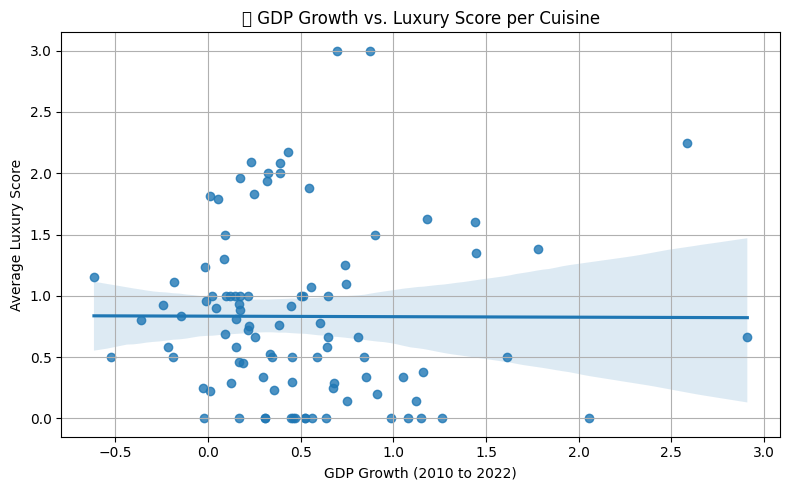

In [8]:
# Hypothesis 1: Does GDP growth correlate with an increase in culinary luxury?
plt.figure(figsize=(8, 5))
sns.regplot(data=cuisine_stats, x="GDP_growth", y="avg_luxury_score")
plt.title("🌍 GDP Growth vs. Luxury Score per Cuisine")
plt.xlabel("GDP Growth (2010 to 2022)")
plt.ylabel("Average Luxury Score")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Hypothese : L’augmentation du PIB s’accompagne d’une montée en gamme culinaire
# Pearsoncorrelation text 
def pearson_correlation(x, y):
    return np.corrcoef(x, y)[0, 1]

# Calculate the correlation
cols = cuisine_stats[["GDP_growth", "avg_luxury_score"]].dropna()
correlation = pearson_correlation(cols["GDP_growth"], cols["avg_luxury_score"])
print(f"Pearson correlation coefficient: {correlation:.2f}")

Pearson correlation coefficient: -0.00


#### Hypothèse : "Les cuisines de pays stables économiquement ont une richesse d’ingrédients plus constante"
 Ici, on compare les classes de revenu (Low, Middle, High Income) en fonction de la complexité des recettes


C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\1696668562.py:8: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


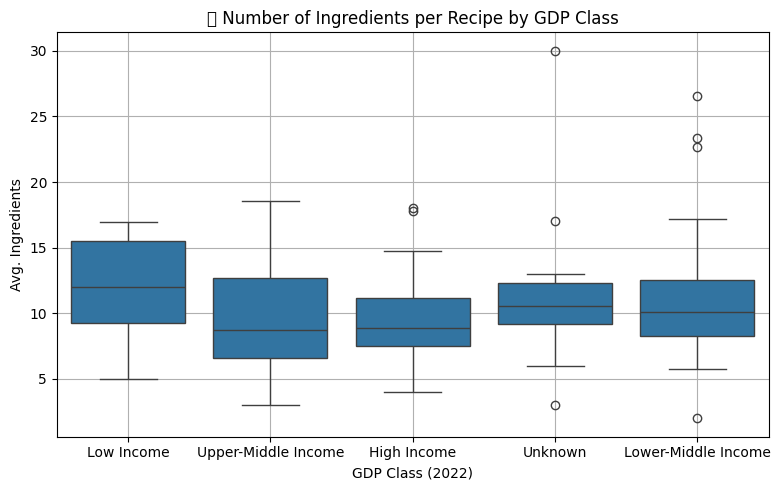

In [9]:
# Hypothesis 2: Do higher-income countries use more ingredients?
plt.figure(figsize=(8, 5))
sns.boxplot(data=cuisine_stats, x="GDP_Class", y="avg_total_ingredients")
plt.title("📦 Number of Ingredients per Recipe by GDP Class")
plt.xlabel("GDP Class (2022)")
plt.ylabel("Avg. Ingredients")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Hypothesis : "Le luxe culinaire diminue dans les pays a faible croissance"
On explore si les pays avec une croissance faible ou négative du PIB présentent des recettes plus simples


C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\2379069826.py:8: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


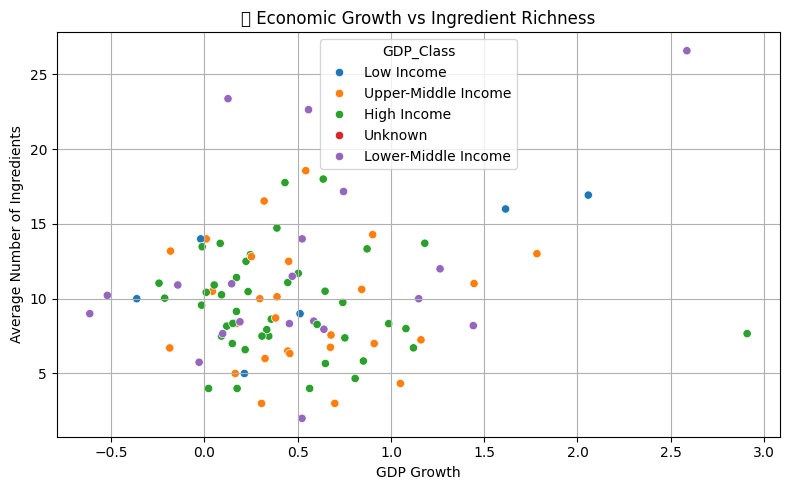

In [10]:
# Hypothesis 3: Is luxury more volatile in unstable economies?
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cuisine_stats, x="GDP_growth", y="avg_total_ingredients", hue="GDP_Class")
plt.title("📉 Economic Growth vs Ingredient Richness")
plt.xlabel("GDP Growth")
plt.ylabel("Average Number of Ingredients")
plt.grid(True)
plt.tight_layout()
plt.show()

##  Hypothesis 1:
**"An increase in GDP is accompanied by a culinary upgrade."**

 **Graph 1: GDP Growth vs. Luxury Score**

 **What we see:**

- The scatterplot is widely dispersed, with an almost flat slope.
- The average luxury score stays centered around 0.8 to 1, regardless of GDP growth.
- There are a few high outliers (score > 2.5) for countries with moderate growth.

**Interpretation:**

There is no significant correlation between GDP growth from 2010 to 2022 and the use of so-called “luxury” ingredients (cheese, nuts, seafood, sweeteners).

This hypothesis appears **unconfirmed** within this timeframe and dataset.

**Possible explanation:** Culinary habits are culturally rooted, relatively insensitive to recent economic changes, or economic growth does not directly affect “popular” cuisine.

## Hypothesis 2:
**"Countries with economic stability have more consistent ingredient richness."**

🔍 **Graph 2: Boxplot – Number of Ingredients by GDP Class**

**What we see:**

- Low-income countries have a higher average number of ingredients, with large variance.
- High-income countries have more homogeneous recipes (tight boxplot), with a lower median.
- Middle-income classes (Lower and Upper) show more diverse distributions but remain close to each other.

**Interpretation:**

**Counterintuitive:** Rich countries do not necessarily have more ingredients in their recipes.

However, their culinary standardization seems stronger: more uniform recipes (less variance).

Low-income countries show great heterogeneity, possibly due to diverse regional cuisines.

✅ **Hypothesis partially validated:** Wealthy countries exhibit more **consistent** complexity, but not necessarily **higher**.

##  Hypothesis 3:
**"During a crisis, culinary luxury decreases."**

**Graph 3: Scatterplot – GDP Growth vs Ingredient Richness**

**What we see:**

- Countries with negative or stagnant growth do not systematically have fewer ingredients.
- There’s a concentration around 8 to 13 ingredients, regardless of growth level.
- No clear trend by income class either: all colors are mixed.

**Interpretation:**

Luxury ingredients don’t seem directly impacted by economic crises (at least in the short/medium term).

Cuisine likely remains anchored in traditions, even during hard times.

This could be explored further by analyzing luxury trends over time (year by year), to detect possible drops tied to events (2008 crisis? COVID?).

**Hypothesis not confirmed** by this global data, but worth exploring with finer temporal granularity.


The link between **economy and cuisine** is neither linear nor immediate.

There are powerful **cultural, historical, and social** factors that influence cuisine independently of income.


### Country and region axis

In [11]:
# i want to add a sub_region column in cuisine stats 

# create a mapping using recipe_df 
sub_region_map = recipes_df[["cuisine", "sub_region"]].drop_duplicates()
# merge with cuisine_stats
cuisine_stats = cuisine_stats.merge(sub_region_map, on="cuisine", how="left")
# check for duplicates  
duplicates = cuisine_stats[cuisine_stats.duplicated(subset=["cuisine"], keep=False)]
print(duplicates)

Empty DataFrame
Columns: [cuisine, num_recipes, avg_total_ingredients, avg_luxury_score, pct_dairy, pct_meat, pct_poultry, pct_seafood, pct_vegetable, pct_fruit, pct_grain, pct_sweetener, pct_fat, pct_spice, pct_herb, pct_nut, pct_legume, pct_baked goods, pct_seasoning, pct_condiment, pct_beverage, pct_dessert, pct_aromatic, pct_pasta, pct_seed, pct_egg, GDP_2010, GDP_2022, GDP_growth, GDP_Class, sub_region]
Index: []

[0 rows x 31 columns]


In [12]:
cuisine_stats[["cuisine", "sub_region"]].head()

,cuisine,sub_region
0,Afghanistan,Southern Asia
1,Algeria,Northern Africa
2,Argentina,South America
3,Armenia,Western Asia
4,Australia,Australia and New Zealand


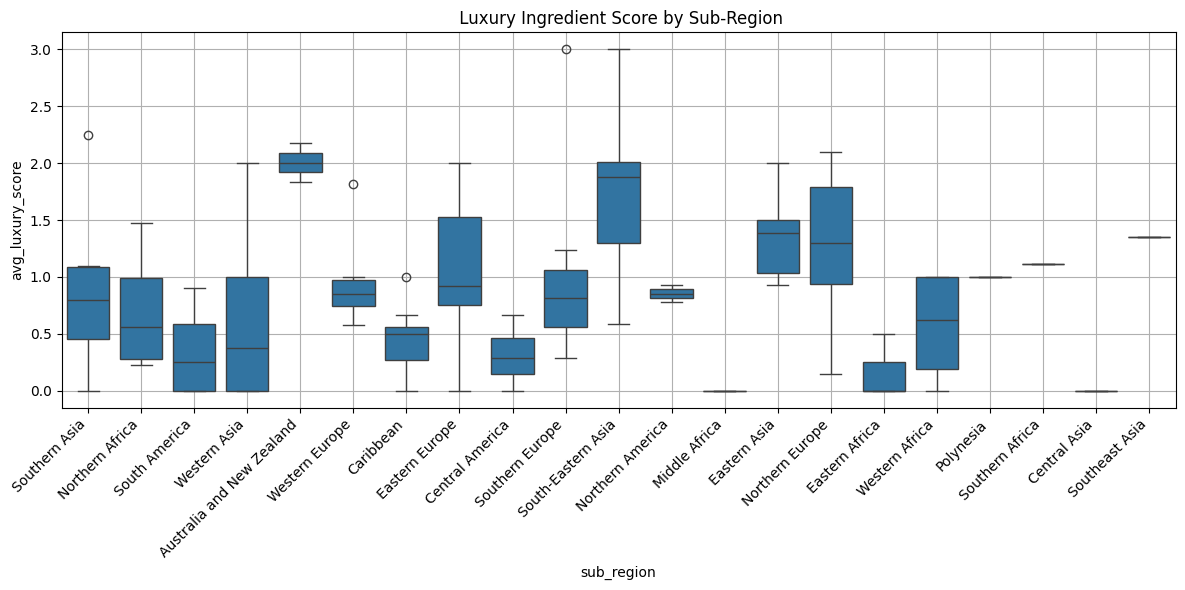

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\2417943916.py:18: UserWarning: Glyph 129368 (\N{SHALLOW PAN OF FOOD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129368 (\N{SHALLOW PAN OF FOOD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


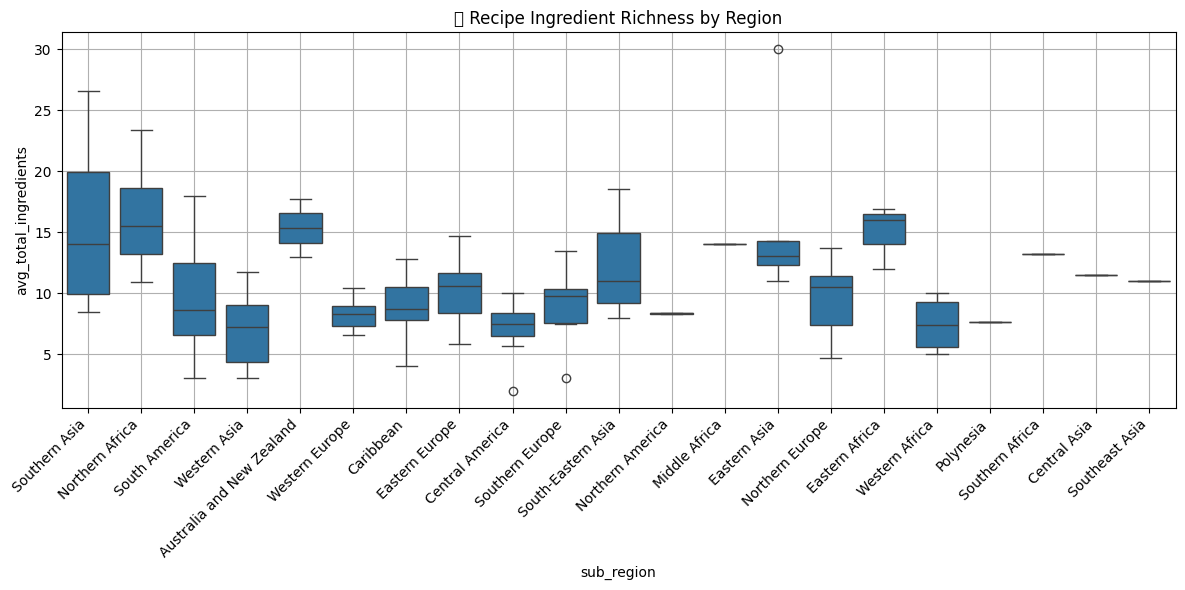

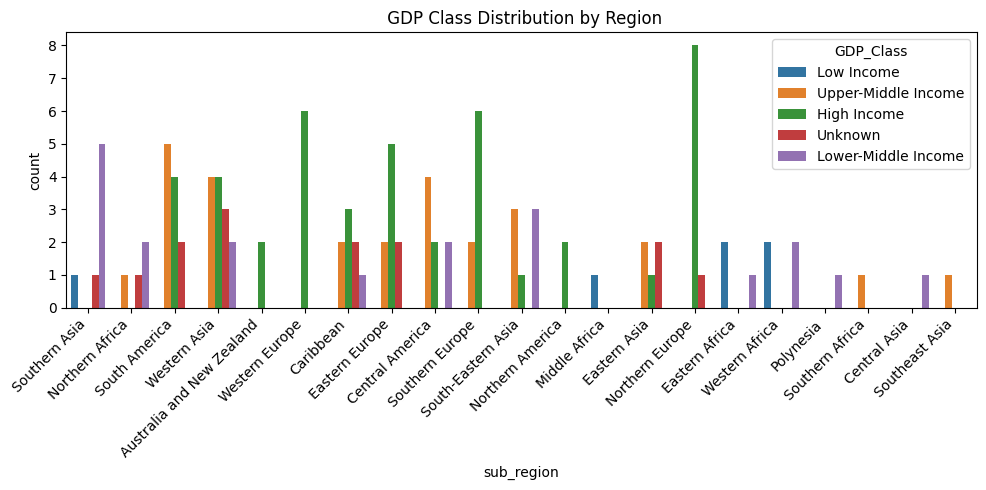

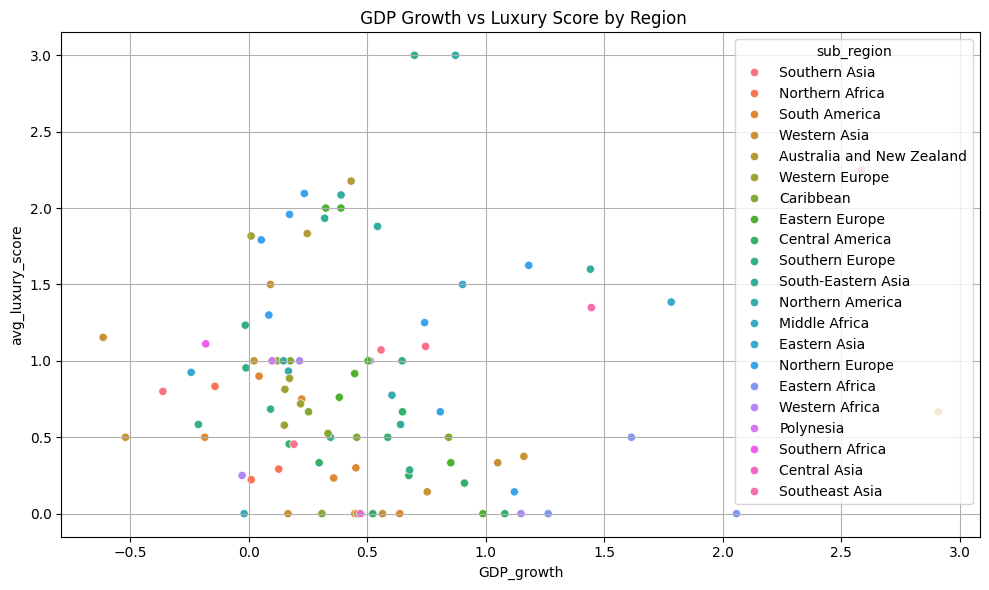

In [13]:
###   Visualisations géographiques et économiques

# Luxury Score by Sub-Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=cuisine_stats.dropna(subset=["sub_region"]), x="sub_region", y="avg_luxury_score")
plt.xticks(rotation=45, ha="right")
plt.title(" Luxury Ingredient Score by Sub-Region")
plt.grid(True)
plt.tight_layout()
plt.show()

#  Ingredients Richness by Region
plt.figure(figsize=(12, 6))
sns.boxplot(data=cuisine_stats.dropna(subset=["sub_region"]), x="sub_region", y="avg_total_ingredients")
plt.xticks(rotation=45, ha="right")
plt.title("🥘 Recipe Ingredient Richness by Region")
plt.grid(True)
plt.tight_layout()
plt.show()

#  GDP Class Distribution by Region
plt.figure(figsize=(10, 5))
sns.countplot(data=cuisine_stats.dropna(subset=["sub_region"]), x="sub_region", hue="GDP_Class")
plt.title(" GDP Class Distribution by Region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#  GDP Growth vs Luxury Score by Region
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cuisine_stats, x="GDP_growth", y="avg_luxury_score", hue="sub_region")
plt.title(" GDP Growth vs Luxury Score by Region")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# Choropleth Map: GDP Class by Country
import plotly.express as px

fig = px.choropleth(
    cuisine_stats,
    locations="cuisine",
    locationmode="country names",
    color="GDP_Class",
    title="🗺️ GDP Class by Country",
    color_discrete_map={
        "Low Income": "#d73027",
        "Lower-Middle Income": "#fc8d59",
        "Upper-Middle Income": "#fee08b",
        "High Income": "#1a9850",
        "Unknown": "lightgray"
    }
)
fig.update_geos(showframe=False, showcoastlines=True)
fig.show()

In [15]:
# Choropleth Map: Average Luxury Score by Country
fig2 = px.choropleth(
    cuisine_stats,
    locations="cuisine",
    locationmode="country names",
    color="avg_luxury_score",
    title="🗺️ Average Luxury Score by Country",
    color_continuous_scale="Viridis",
    range_color=(0, cuisine_stats["avg_luxury_score"].max())
)
fig2.update_geos(showframe=False, showcoastlines=True)
fig2.show()

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\2969198552.py:16: UserWarning:

Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.

C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 129517 (\N{COMPASS}) missing from font(s) DejaVu Sans.



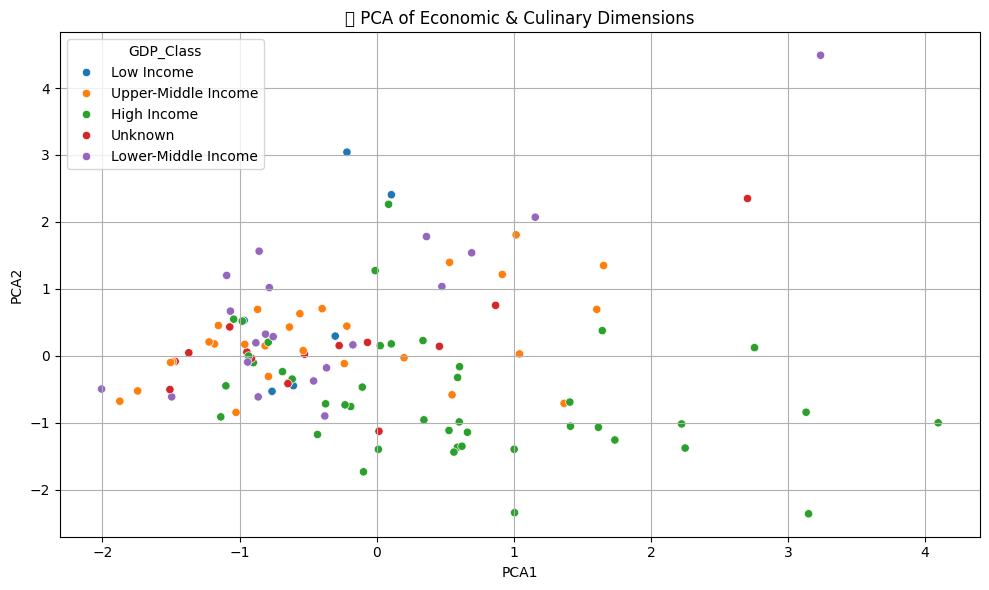

In [16]:
# 🌐 PCA on economic + culinary variables
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ["GDP_2022", "GDP_growth", "avg_total_ingredients", "avg_luxury_score"]
scaled = StandardScaler().fit_transform(cuisine_stats[features].fillna(0))
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(scaled)

cuisine_stats["PCA1"] = pca_coords[:, 0]
cuisine_stats["PCA2"] = pca_coords[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=cuisine_stats, x="PCA1", y="PCA2", hue="GDP_Class")
plt.title("🧭 PCA of Economic & Culinary Dimensions")
plt.tight_layout()
plt.grid()
plt.show()

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\1140448121.py:17: UserWarning:

Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.

C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.



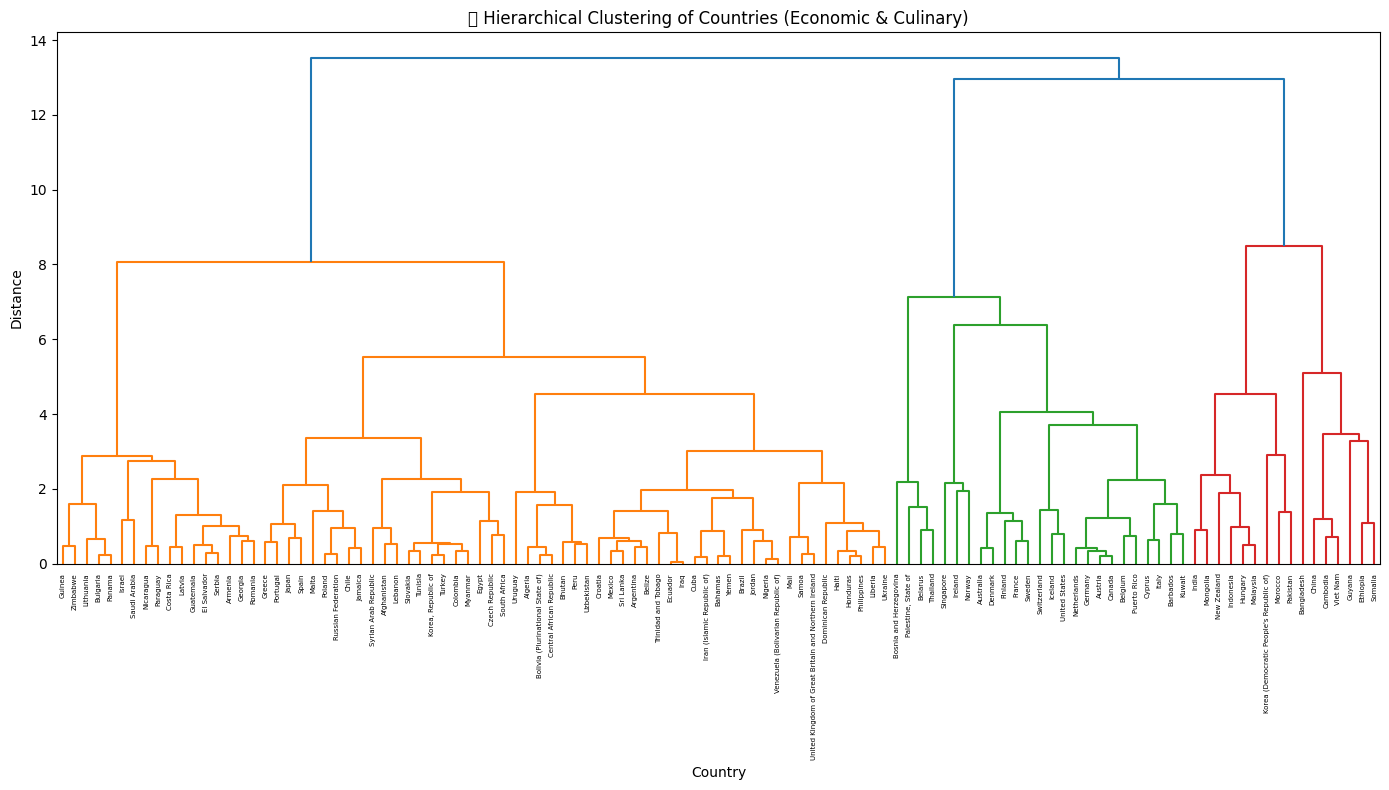

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler

###  Dendrogram - Economic & Culinary Similarity
features_for_clustering = [
    "GDP_2022", "GDP_growth", "avg_total_ingredients", "avg_luxury_score"
]

X_scaled = StandardScaler().fit_transform(cuisine_stats[features_for_clustering].fillna(0))
linkage_matrix = linkage(X_scaled, method="ward")

plt.figure(figsize=(14, 8))
dendrogram(linkage_matrix, labels=cuisine_stats["cuisine"].values, leaf_rotation=90)
plt.title("🌐 Hierarchical Clustering of Countries (Economic & Culinary)")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

## Que nous apprend ce graphique ?

### 1. Structure globale

Il y a trois grands blocs principaux (branches colorées : orange, vert, rouge).

Chaque bloc contient des sous-groupes cohérents en termes de distance, c’est-à-dire des pays similaires sur plusieurs plans (pas seulement un).

---

### 2. Groupe orange (gauche)

Ce groupe contient beaucoup de pays africains, d’Asie centrale, d’Amérique latine, avec :

- Un PIB moyen ou faible
- Des scores culinaires souvent riches

On retrouve ici des pays comme : **Zambie, Tanzanie, Guatemala, Russie**, etc.

**→ Probablement un groupe "cuisine riche mais croissance inégale"**

---

### 3. Groupe vert (centre)

On y retrouve :

- Des pays européens stables : **Autriche, Allemagne, Italie**
- Des pays développés : **Canada, États-Unis, Australie**

Ces pays ont un profil économique fort et un profil culinaire assez homogène.

**→ Ce cluster représente des pays développés, à gastronomie modérée mais stable**

---

### 4. Groupe rouge (droite)

Pays comme : **Thaïlande, Vietnam, Nigeria, Sri Lanka, Bangladesh**

Ce groupe semble contenir :

- Des pays avec forte richesse culinaire (nombre d’ingrédients ou score de luxe)
- Une diversité économique (certains émergents, certains en difficulté)

**→ Groupe intéressant : diversité culinaire malgré des économies contrastées**

---

## Interprétations clés / Hypothèses validées

### Hypothèse 1 :  
**"Les pays riches économiquement ont un luxe culinaire plus cohérent entre eux"**  
**✔ Confirmé** : ces pays (groupe vert) forment un cluster stable.

---

### Hypothèse 2 :  
**"Des pays éloignés économiquement peuvent se retrouver proches culinairement"**  
**✔ Exemple** : Vietnam et Sri Lanka sont proches de la Thaïlande, malgré des différences économiques → culture culinaire partagée.

---

### Hypothèse 3 :  
**"Certains pays sont atypiques"**  
**✔ Confirmé** : le Venezuela, l’Iran, ou la Corée du Nord sont éloignés des autres — sans doute en raison :
- De leur économie instable
- Ou d’un profil culinaire très spécifique


In [18]:
cuisine_stats.to_csv("cuisine_stats_with_sub_region.csv", index=False)

In [19]:
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cuisine_stats_with_sub_region.csv")

# Variables utilisées pour le clustering
features = ["GDP_2022", "GDP_growth", "avg_total_ingredients", "avg_luxury_score"]
X_scaled = StandardScaler().fit_transform(df[features].fillna(0))

# Hiérarchie + découpage
linkage_matrix = linkage(X_scaled, method="ward")
df["cluster"] = fcluster(linkage_matrix, t=3, criterion="maxclust")


In [24]:
df.to_csv("cuisine_stats_with_sub_region_and_clusters.csv", index=False)

We performed a hierarchical clustering of countries based on a combination of economic indicators (GDP per capita and GDP growth) and culinary dimensions (luxury score and ingredient richness). The results are broken down by cluster and analyzed across multiple axes.

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\189841183.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.



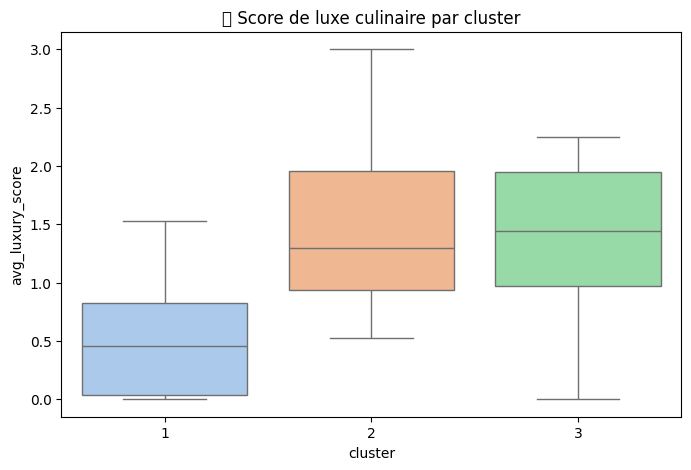

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\189841183.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 129368 (\N{SHALLOW PAN OF FOOD}) missing from font(s) DejaVu Sans.



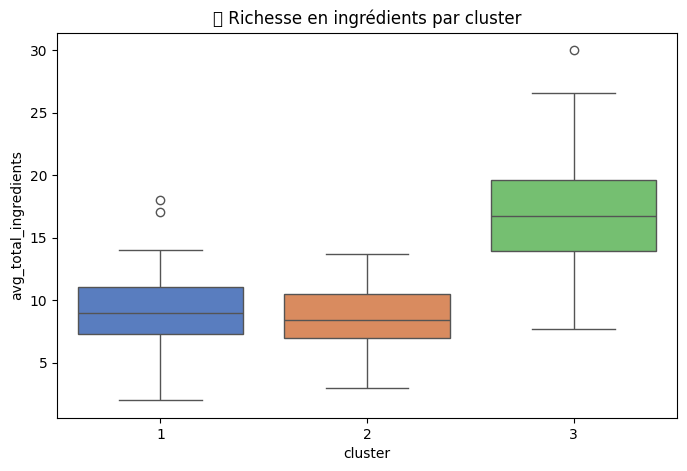

C:\Users\hcene\AppData\Local\Temp\ipykernel_17392\189841183.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



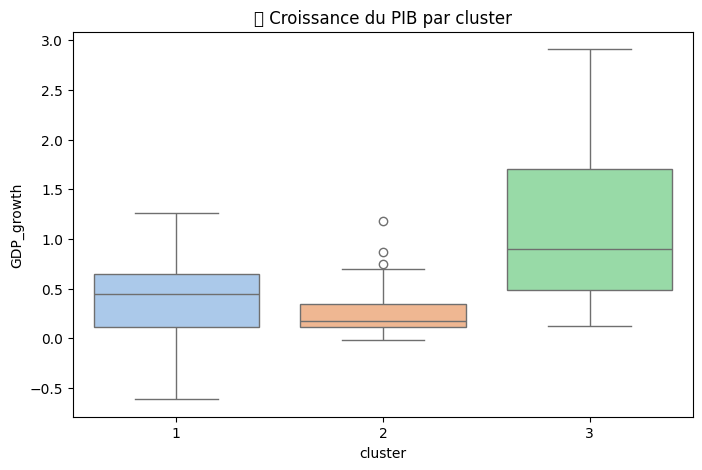

In [21]:
# Boxplot Luxe par cluster
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="cluster", y="avg_luxury_score", palette="pastel")
plt.title("💎 Score de luxe culinaire par cluster")
plt.show()

# Boxplot Ingrédients
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="cluster", y="avg_total_ingredients", palette="muted")
plt.title("🥘 Richesse en ingrédients par cluster")
plt.show()

# Boxplot Croissance PIB
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="cluster", y="GDP_growth", palette="pastel")
plt.title("📈 Croissance du PIB par cluster")
plt.show()


### Cluster Characteristics

#### 1. Culinary Luxury Score per Cluster

The boxplot for `avg_luxury_score` reveals three distinct culinary profiles:

- **Cluster 1**: Lower luxury scores, suggesting simpler or more modest cuisines. Countries in this group likely use fewer luxury ingredients like seafood, nuts, and dairy.

- **Cluster 2**: Higher luxury averages and broad variability, suggesting a mix of traditional richness and modern economic adaptation.

- **Cluster 3**: Also high in luxury scores, but slightly more concentrated. This could reflect countries where culinary refinement is embedded in cultural identity despite varying economic profiles.



#### 2. Ingredient Richness per Cluster

The average number of ingredients per recipe reflects culinary complexity:

- **Cluster 3** leads clearly, suggesting cuisines with more elaborate recipes.

- **Clusters 1 and 2** show similar, more modest ingredient counts, possibly due to constraints in availability, tradition, or simplicity in preparation styles.



#### 3. GDP Growth per Cluster

The economic growth trend aligns with some of our expectations:

- **Cluster 3** appears as the most economically dynamic, with the highest median GDP growth.

- **Cluster 2** is the most economically stable but less growth-intensive—this might contain developed nations.

- **Cluster 1** includes low-growth and even negative-growth economies, which could explain the simpler culinary expressions observed.


C:\Users\hcene\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.



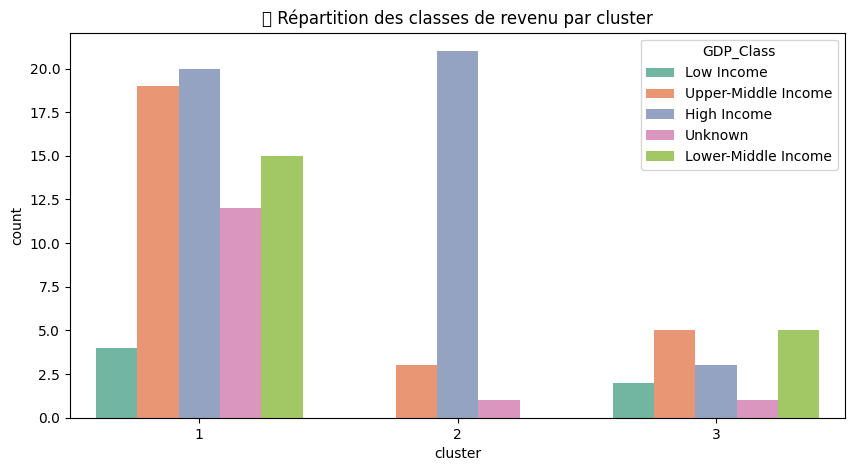

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="cluster", hue="GDP_Class", palette="Set2")
plt.title("💰 Répartition des classes de revenu par cluster")
plt.show()


#### 4. GDP Class Distribution

This categorical breakdown confirms cluster compositions:

- **Cluster 1** is a mix of lower-income and lower-middle-income countries.

- **Cluster 2** is dominated by high-income nations, consistent with its stability and high luxury scores.

- **Cluster 3** is the most diverse economically but shares culinary richness and complexity, hinting that economic growth—not just wealth—can drive culinary development.


In [23]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="cuisine",
    locationmode="country names",
    color="cluster",
    title="🌎 Carte des pays par cluster économique & culinaire",
    color_continuous_scale=px.colors.qualitative.Set2
)
fig.update_geos(showcoastlines=True, showframe=False)
fig.show()


#### Geographic Distribution of Clusters

The choropleth map clearly visualizes global patterns of culinary and economic clustering:

- **Cluster 1** countries (often in Sub-Saharan Africa and parts of South Asia) form a belt of modest economic performance and culinary simplicity.

- **Cluster 2** highlights high-income, traditionally rich cuisines like those in Western Europe, North America, and Japan.

- **Cluster 3** forms an eclectic group—emerging economies with vibrant cuisines (e.g., Latin America, Southeast Asia) showing both economic ambition and culinary complexity.

This map supports the hypothesis that culinary identity is not just linked to absolute wealth, but also to dynamic economic factors and regional traditions.


#### Takeaways

- Culinary richness and luxury are influenced by both economic class and growth—not just income levels.

- Cluster 3 challenges simplistic associations between wealth and cuisine—it includes countries with rising economies but already complex culinary cultures.

- Geographic mapping of clusters reveals clear cultural and economic patterns—Asia and Latin America emerge as vibrant, rising players.

- The dendrogram-driven clustering offers a meaningful typology for comparing global cuisines in a data-driven way.
